<H1>HOMEWORK - 5

<h4> Step 1 : Import Libraries

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt


<h4>Step 2: Load Dataset</h4>

In [13]:
housing = pd.read_csv("data/kc_house_data_original.csv")

In [14]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [15]:
housing.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


From the above data we can see that the date format is not proper. So we will need to correct the date format.

In [5]:
housing["date"] = pd.to_datetime(housing["date"])

In [6]:
housing.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


<H3>SCATTERPLOT</H3>

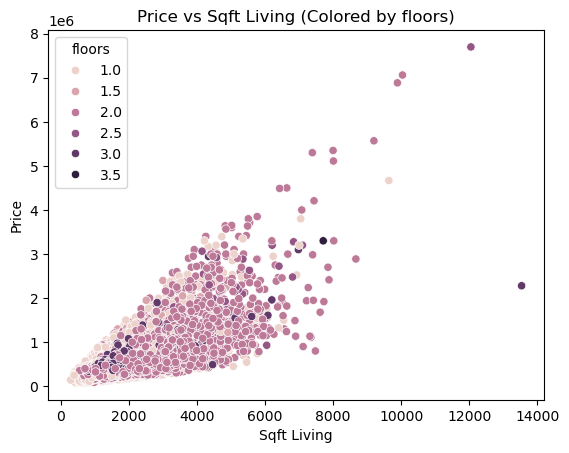

In [22]:
sns.scatterplot(
    data = housing,
    x="sqft_living",
    y="price",
    hue ="floors",
   )
plt.title("Price vs Sqft Living (Colored by floors)")
plt.xlabel("Sqft Living")
plt.ylabel("Price")
plt.show()

<span style="color:purple"> **INTERPRETATION: <BR> There is a strong relationship between sqft_living and price. As the living area increases, housing prices tend to increase significantly.As far as number of floors are concerned, we can see that there are a few homes which have floors between 2.5 -3.5 and their sqft living is very less, the price for these homes are alos less. So, uttimately sqft_living actually affects the price the house. Higher the sqft higher the price.** </span>

<H3> FACETED HISTOGRAM</H3>

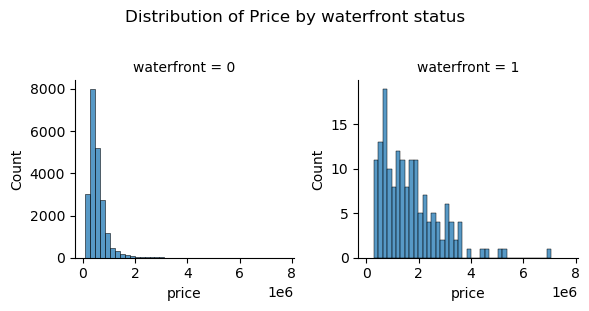

In [24]:
histo = sns.FacetGrid(housing, col="waterfront", margin_titles=True, sharey=False)
histo.map(sns.histplot, "price", bins=40)
histo.fig.suptitle("Distribution of Price by waterfront status", y=1.02)
plt.tight_layout()
plt.show()

<span style="color:darkblue"> **INTERPRETATION: <BR> The Facated graph above shows the distribution of price by Waterfront Status. Waterfront properties are less in this dataset but are priced significantly higher on average. The non-waterfront distribution is much more concentrated at lower price points where as waterfront homes show more price variability**.

<h3> TIME SERIES PLOT</h3>

In [25]:
housing["date"] = pd.to_datetime(housing["date"])

In [26]:
housing["month"] = housing["date"].dt.to_period("M")

In [27]:
monthly_sales = housing.groupby("month").size().reset_index(name="count")
monthly_sales["month"] = monthly_sales["month"].astype(str)

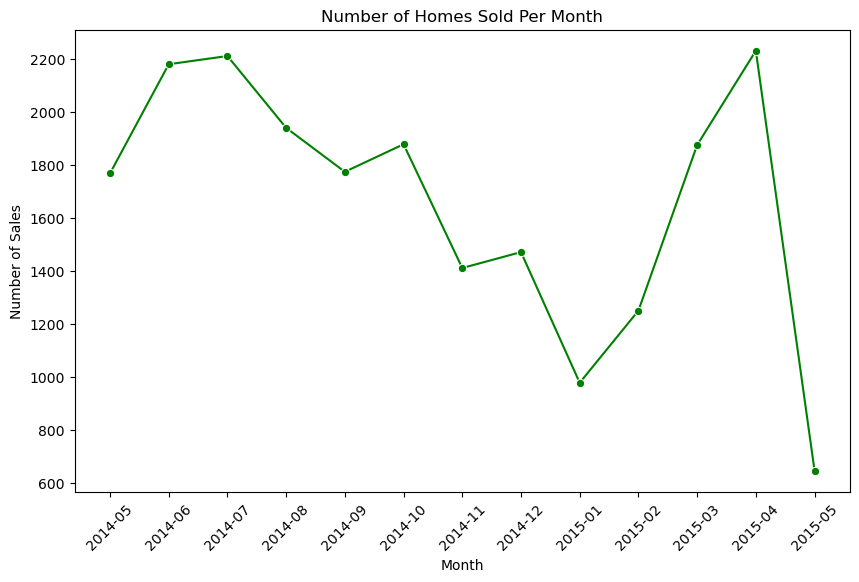

In [28]:
plt.figure(figsize=(10,6))

sns.lineplot(data=monthly_sales, x="month", y="count", marker="o", color = "green")

plt.xticks(rotation=45)
plt.title("Number of Homes Sold Per Month")
plt.xlabel("Month")
plt.ylabel("Number of Sales")

plt.show()

<span style="color:green"> **INTERPRETATION: <BR>The above graph shows the number of homes sold per month. In the graph we can see the seasonality effect. From the peak in June-July there is a downward trend for the houses sold.This downward trend continues till January, after which it begins to increase steadily.**